In [5]:
import chromadb
import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.preprocessing import normalize
import pandas as pd

# 1. ChromaDB 연결
client = chromadb.PersistentClient(path="/Users/nanahyun/Documents/GitHub/final_develop/data/chroma_db(스케치, 2만개)")  # 경로 맞게 수정
collection = client.get_collection("design")  # 컬렉션명 수정

# 2. 벡터 전체 추출 (2만장)
results = collection.get(include=["embeddings", "metadatas"])
embeddings = np.array(results["embeddings"])  # (20000, 512)
ids = results["ids"]

print(f"임베딩 shape: {embeddings.shape}")

# 3. L2 정규화 (CLIP 벡터는 정규화하면 성능 좋아짐)
embeddings_norm = normalize(embeddings, norm="l2")

# 4. K-Means 클러스터링
# 2만장이면 MiniBatchKMeans가 훨씬 빠름
N_CLUSTERS = 50  # 원하는 클러스터 수로 조정

kmeans = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    batch_size=1024,
    n_init=3
)
labels = kmeans.fit_predict(embeddings_norm)
print(f"클러스터링 완료!")

# 5. 결과 저장
df = pd.DataFrame({
    "id": ids,
    "cluster": labels
})
df.to_csv("cluster_results.csv", index=False)
print(df["cluster"].value_counts().sort_index())

임베딩 shape: (21801, 512)
클러스터링 완료!
cluster
0     534
1     627
2     479
3     667
4     227
5     297
6     542
7     224
8     483
9     459
10    564
11    301
12    489
13    419
14    530
15    215
16    529
17    461
18    424
19    483
20    906
21    572
22    717
23    470
24    105
25    708
26    333
27    548
28    313
29    459
30    476
31    435
32    509
33    418
34    561
35    120
36    400
37    322
38    395
39    539
40    365
41    223
42    172
43    692
44    220
45    630
46    165
47    537
48    138
49    399
Name: count, dtype: int64


### 적합한 k 개수 찾기 (꺾이는 지점)

k=10 완료
k=20 완료
k=30 완료
k=40 완료
k=50 완료
k=60 완료
k=70 완료
k=80 완료
k=90 완료
k=100 완료
k=110 완료
k=120 완료
k=130 완료
k=140 완료
k=150 완료
k=160 완료
k=170 완료
k=180 완료
k=190 완료


Matplotlib is building the font cache; this may take a moment.
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_39395/2797529300.py:15: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.savefig("elbow.png")
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_39395/2797529300.py:15: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.savefig("elbow.png")
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_39395/2797529300.py:15: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.savefig("elbow.png")
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_39395/2797529300.py:15: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.savefig("elbow.png")
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_39395/2797529300.py:15: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) De

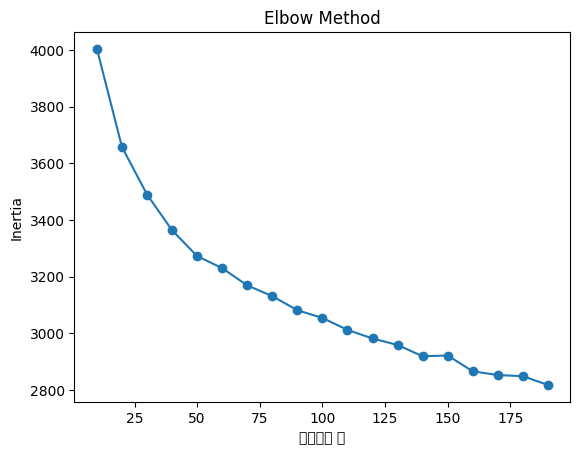

In [6]:
inertias = []
K_range = range(10, 200, 10)

for k in K_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3)
    km.fit(embeddings_norm)
    inertias.append(km.inertia_)
    print(f"k={k} 완료")

import matplotlib.pyplot as plt
plt.plot(K_range, inertias, "o-")
plt.xlabel("클러스터 수")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.savefig("elbow.png")

/opt/miniconda3/envs/final_develop/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP 차원 축소 중... (2~3분 걸릴 수 있어)


/opt/miniconda3/envs/final_develop/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 완료!


/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_39395/3903730017.py:34: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_39395/3903730017.py:34: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_39395/3903730017.py:34: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_39395/3903730017.py:34: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_39395/3903730017.py:34: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipy

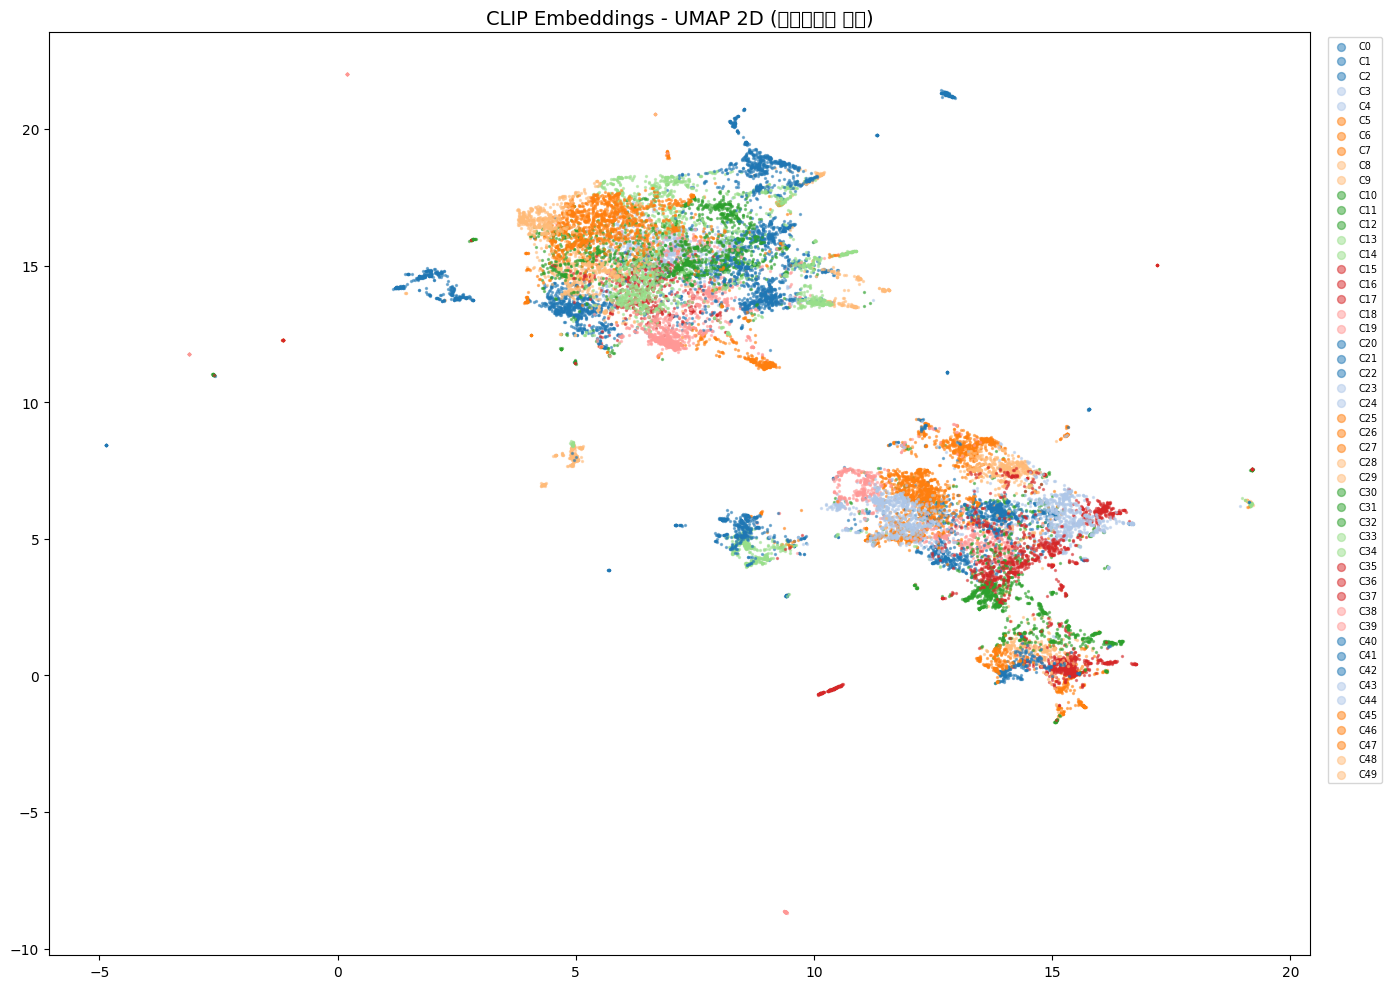

umap_clusters.png 저장 완료!


In [ ]:
import umap
import matplotlib.pyplot as plt
import matplotlib.cm as cm

print("UMAP 차원 축소 중... (2~3분 걸릴 수 있어)")
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",   # CLIP 벡터는 cosine이 적합
    random_state=42
)
embedding_2d = reducer.fit_transform(embeddings_norm)  # (20000, 2)
print("UMAP 완료!")

# 시각화
fig, ax = plt.subplots(figsize=(14, 10))

colors = cm.tab20(np.linspace(0, 1, N_CLUSTERS))

for cluster_id in range(N_CLUSTERS):
    mask = labels == cluster_id
    ax.scatter(
        embedding_2d[mask, 0],
        embedding_2d[mask, 1],
        s=2,                      # 점 크기 (2만장이라 작게)
        color=colors[cluster_id % 20],
        alpha=0.5,
        label=f"C{cluster_id}"
    )

ax.set_title("CLIP Embeddings - UMAP 2D (cluster's color)", fontsize=14)
ax.legend(markerscale=4, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.savefig("umap_clusters.png", dpi=150)
plt.show()
print("umap_clusters.png 저장 완료!")